# Question : generate some random $d \times d$ matrix $Y$, with iid uniform / normal / pareto entries. 
# Apply column-demeaning
# Take the SVD $Y = U S V^t$, where $S = diag(\psi)$
# 1. Sanity-check the relations
# $0 \le Tr(Y)^2 / Tr(Y^t Y) \le Tr(S)^2 / Tr(S^2) = \nu(\psi)$
# What are necessary and sufficient conditions on $Y$, for the following:
# 2.1. $Tr(Y) / Tr(S) \rightarrow 1$, as $d \rightarrow \infty$
# 2.2. $Tr(Y)^2 / Tr(S)^2 \rightarrow 1$, as $d \rightarrow \infty$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

import PatnaikPearson as pp
import cupy

# 1. Uniform

In [2]:
this_config = pp.trace_Y_trace_S_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_uniform"] = True 
this_config["size_scale"] = size_scale 
#this_config[""] = 

xx_u_ss_100_ni_200 = pp.trace_Y_trace_S_experiment(this_config)

** calculate_nu_cpu ** running on CPU
0 N =  232 , d =  137
trace_Y =  4.148568419250507 , trace_S =  552.8377437699918 , trace_Y / trace_S =  0.007504133836738397
trace_YtY =  2640.960394260823 , trace_Ssquared =  2640.9603942608246 , trace_YtY / trace_Ssquared =  0.9999999999999993
(trace_Y ** 2) / (trace_YtY * nu_psi) =  5.631202463968218e-05
(trace_S ** 2) / (trace_Squared * nu_psi) =  1.0
0 5.631202463968217e-05 1.0
** calculate_nu_cpu ** running on CPU
1 N =  166 , d =  162
trace_Y =  6.188967108229675 , trace_S =  513.506615300458 , trace_Y / trace_S =  0.012052361009231492
trace_YtY =  2238.1691926374515 , trace_Ssquared =  2238.169192637451 , trace_YtY / trace_Ssquared =  1.0000000000000002
(trace_Y ** 2) / (trace_YtY * nu_psi) =  0.00014525940589684355
(trace_S ** 2) / (trace_Squared * nu_psi) =  1.0
1 0.00014525940589684355 1.0
** calculate_nu_cpu ** running on CPU
2 N =  226 , d =  142
trace_Y =  1.7032940390430829 , trace_S =  561.7173039161157 , trace_Y / trace_S =  0.003

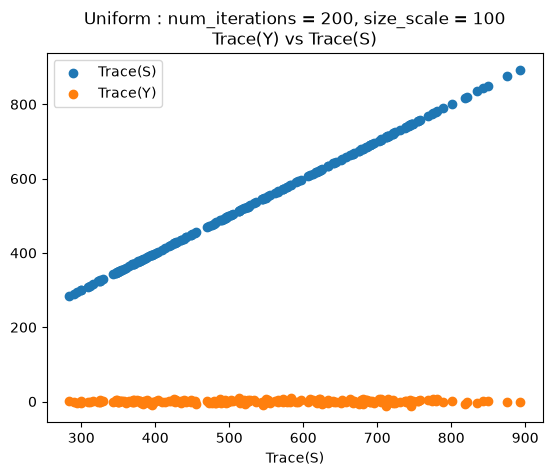

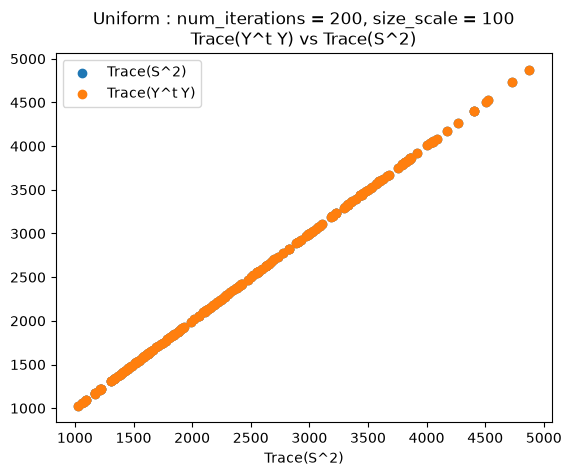


 fY = Trace(Y)^2 / Trace(YtY) 

shape : (200,)
min : 8.480574184996749e-07
max : 0.04928419561585449
sum : 1.117483529803538
mean : 0.005587417649017689
std : 0.00774056416124831
norm : 0.13500782904628614


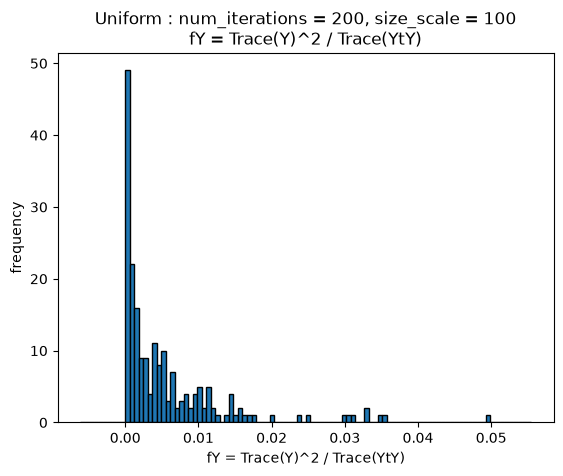


 fS = Trace(S)^2 / Trace(S^2) 

shape : (200,)
min : 78.27859296540849
max : 163.65213228738529
sum : 23654.877018094136
mean : 118.27438509047067
std : 22.350303341461277
norm : 1702.2553408924462


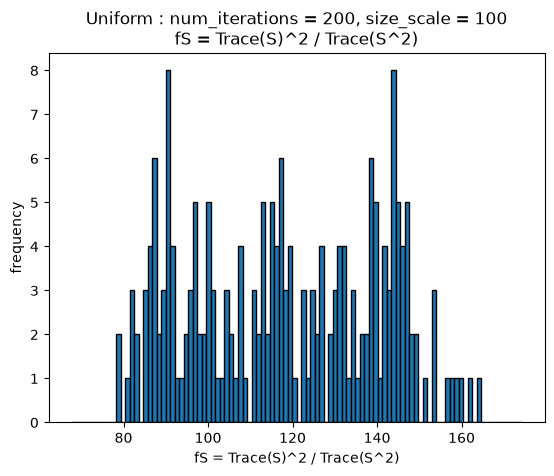

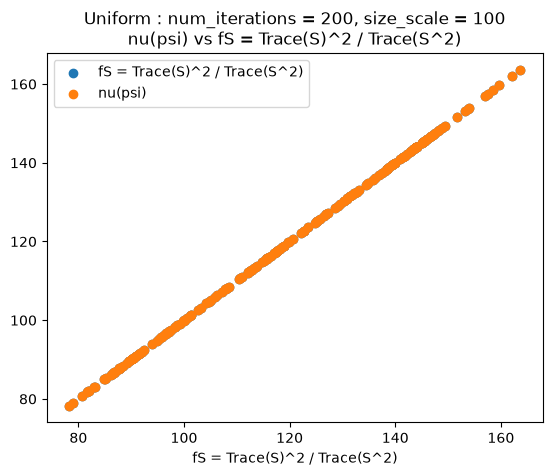


 fY / fS = (Trace(Y)^2 / Trace(YtY)) / Trace(S)^2 / Trace(S^2)) 

shape : (200,)
min : 6.248312802700137e-09
max : 0.0005075675454469819
sum : 0.009863781760791699
mean : 4.93189088039585e-05
std : 7.037783034448572e-05
norm : 0.0012153512882792684


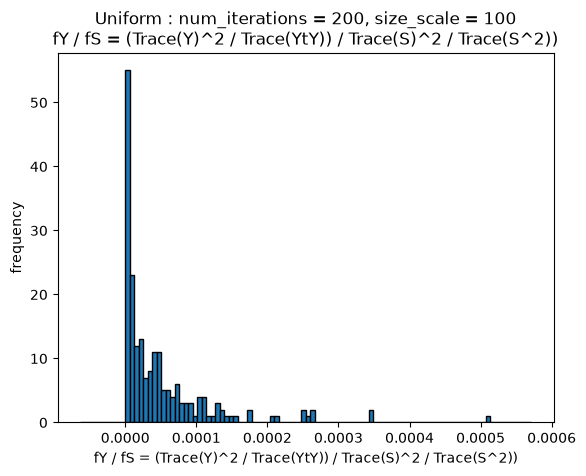


 fS / nu(psi) = (Trace(S)^2 / Trace(S^2)) / nu(psi) 

shape : (200,)
min : 1.0
max : 1.0
sum : 200.0
mean : 1.0
std : 0.0
norm : 14.142135623730951


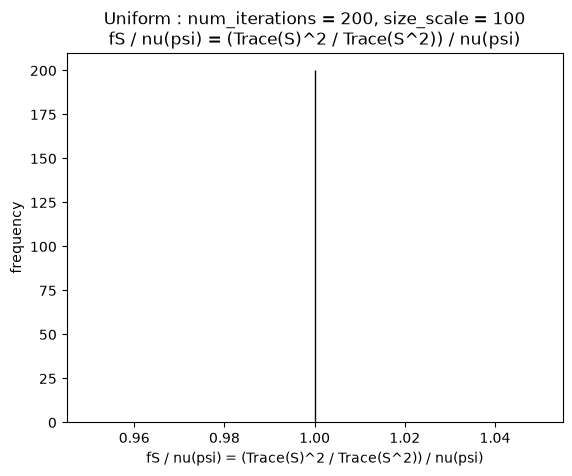


 Trace(Y) / Trace(S) 

shape : (200,)
min : -0.022529259762517316
max : 0.018514880571017918
sum : 0.09007648171052794
mean : 0.00045038240855263973
std : 0.007008285417277525
norm : 0.09931657344467588


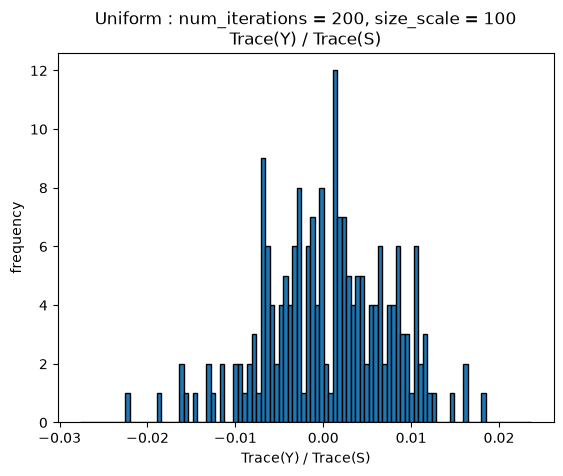


 Trace(YtY) / Trace(S^2) 

shape : (200,)
min : 0.9999999999999988
max : 1.0000000000000016
sum : 200.0
mean : 1.0
std : 5.377423412472531e-16
norm : 14.142135623730951


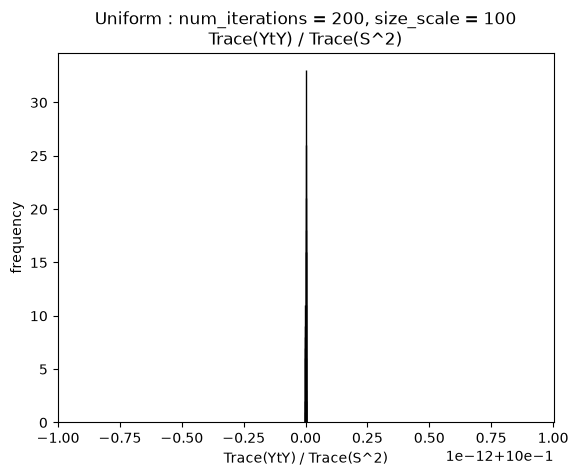

In [3]:
prefix = "Uniform : num_iterations = " + str(num_iterations) + ", size_scale = " + str(size_scale) + "\n"
pp.trace_Y_trace_S_experiment_plot_one(xx_u_ss_100_ni_200, prefix)

# 2. Normal

In [2]:
this_config = pp.trace_Y_trace_S_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_normal"] = True 
this_config["size_scale"] = size_scale 
this_config["column_demean"] = True 

xx_normal_ss_100_ni_200 = pp.trace_Y_trace_S_experiment(this_config)

Y.shape =  (232, 137) , mu_Y.shape =  (137,)
** calculate_nu_cpu ** running on CPU
0 N =  232 , d =  137
trace_Y =  8.441463904945266 , trace_S =  1908.1026873227427 , trace_Y / trace_S =  0.0044240092323277825
trace_YtY =  31553.868959610776 , trace_Ssquared =  31553.868959610765 , trace_YtY / trace_Ssquared =  1.0000000000000004
(trace_Y ** 2) / (trace_YtY * nu_psi) =  1.957185768772145e-05
(trace_S ** 2) / (trace_Squared * nu_psi) =  1.0
0 1.9571857687721453e-05 1.0
Y.shape =  (229, 161) , mu_Y.shape =  (161,)
** calculate_nu_cpu ** running on CPU
1 N =  229 , d =  161
trace_Y =  0.011166296234154771 , trace_S =  2196.754109019407 , trace_Y / trace_S =  5.083088811946828e-06
trace_YtY =  36856.1766574188 , trace_Ssquared =  36856.176657418815 , trace_YtY / trace_Ssquared =  0.9999999999999996
(trace_Y ** 2) / (trace_YtY * nu_psi) =  2.5837791870139025e-11
(trace_S ** 2) / (trace_Squared * nu_psi) =  1.0
1 2.583779187013903e-11 1.0
Y.shape =  (202, 140) , mu_Y.shape =  (140,)
** calc

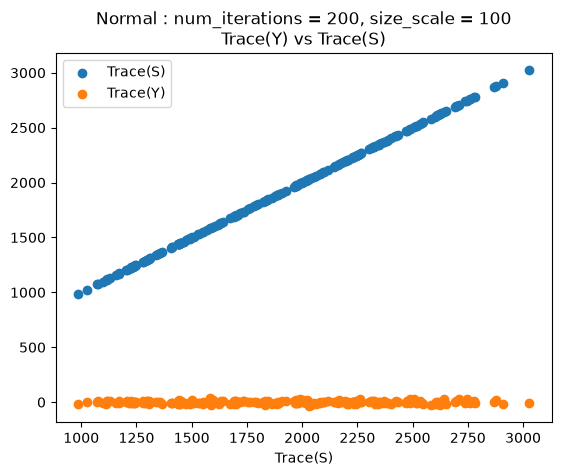

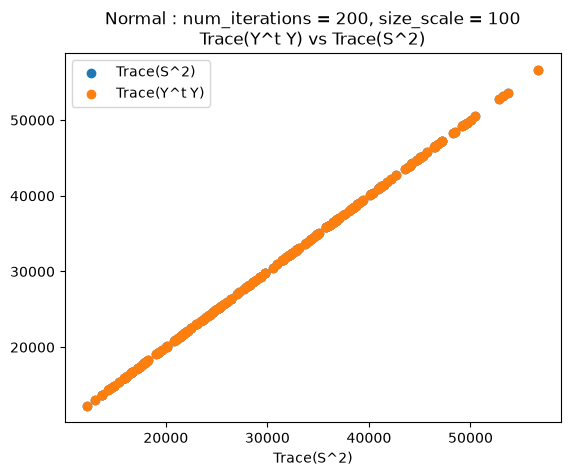


 fY = Trace(Y)^2 / Trace(YtY) 

shape : (200,)
min : 3.383046829514284e-09
max : 0.048824233636329865
sum : 0.9782761522857935
mean : 0.0048913807614289675
std : 0.006908381989202867
norm : 0.11970910363211311


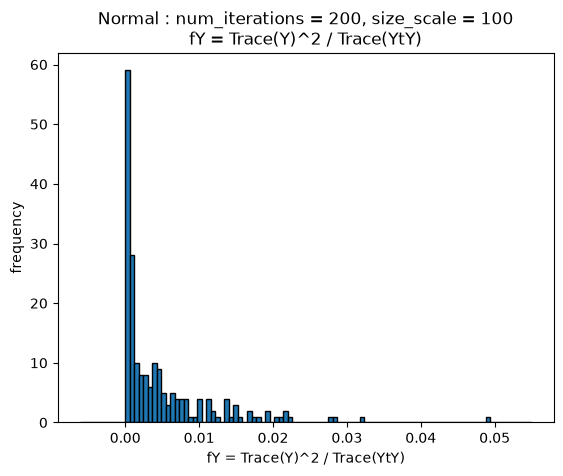


 fS = Trace(S)^2 / Trace(S^2) 

shape : (200,)
min : 79.34070682794727
max : 161.78459333631855
sum : 23835.208491611676
mean : 119.17604245805838
std : 21.509845107768136
norm : 1712.6355439803945


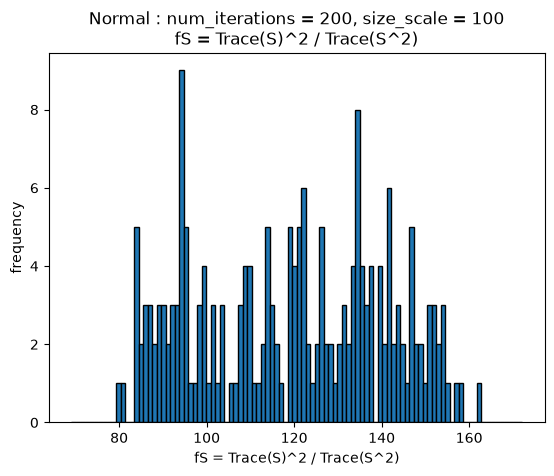

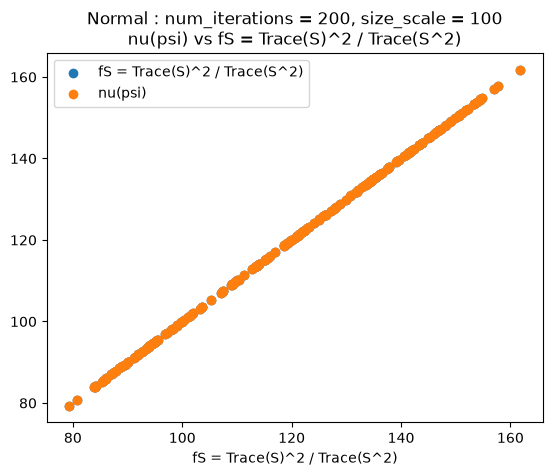


 fY / fS = (Trace(Y)^2 / Trace(YtY)) / Trace(S)^2 / Trace(S^2)) 

shape : (200,)
min : 2.583779187013903e-11
max : 0.0004474717785465196
sum : 0.008699467277495676
mean : 4.349733638747838e-05
std : 6.438830425505107e-05
norm : 0.0010988969012283617


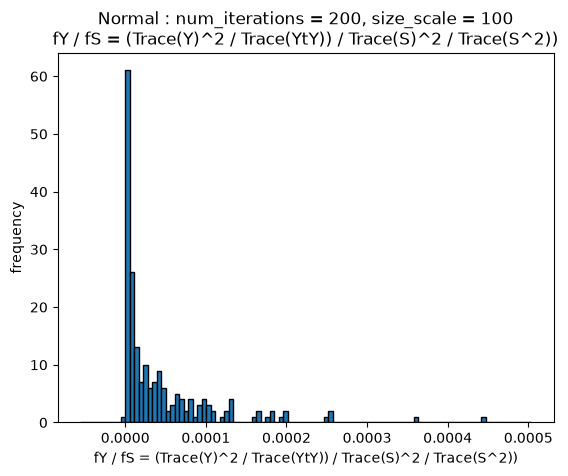


 fS / nu(psi) = (Trace(S)^2 / Trace(S^2)) / nu(psi) 

shape : (200,)
min : 1.0
max : 1.0
sum : 200.0
mean : 1.0
std : 0.0
norm : 14.142135623730951


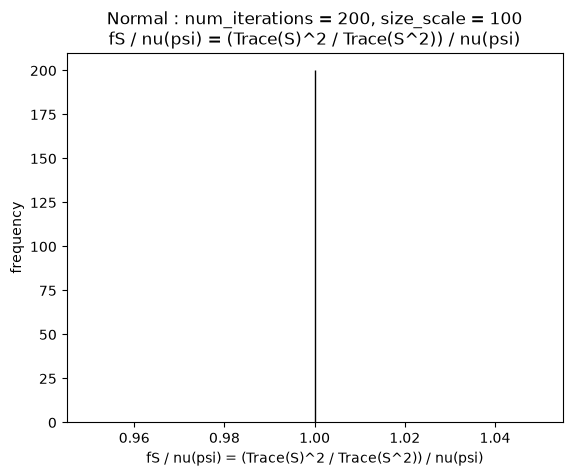


 Trace(Y) / Trace(S) 

shape : (200,)
min : -0.018938961426694295
max : 0.02115352874927773
sum : -0.05527293030170441
mean : -0.00027636465150852207
std : 0.006589458169445722
norm : 0.09327093479479916


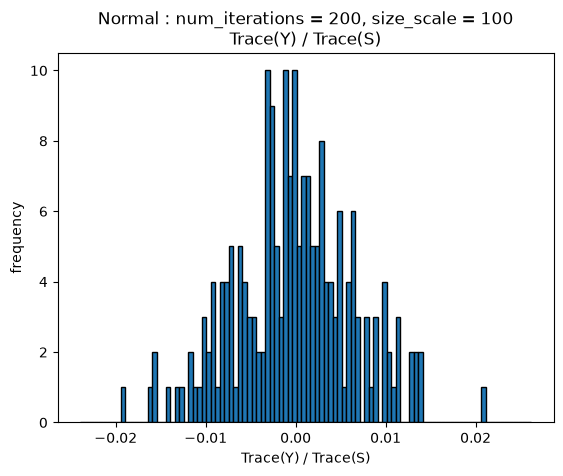


 Trace(YtY) / Trace(S^2) 

shape : (200,)
min : 0.9999999999999986
max : 1.0000000000000016
sum : 200.00000000000003
mean : 1.0000000000000002
std : 5.704429186199679e-16
norm : 14.142135623730953


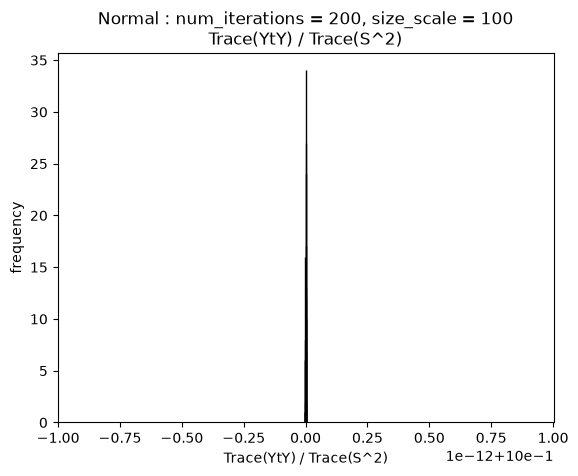

In [3]:
prefix = "Normal : num_iterations = " + str(num_iterations) + ", size_scale = " + str(size_scale) + "\n"
pp.trace_Y_trace_S_experiment_plot_one(xx_normal_ss_100_ni_200, prefix)

# 3. Pareto

In [2]:
this_config = pp.trace_Y_trace_S_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_pareto"] = True 
this_config["size_scale"] = size_scale 
this_config["column_demean"] = True 

min_alpha = 0.1
max_alpha = 3.0
pareto_alpha_vals = np.linspace(min_alpha, max_alpha, num_iterations)
this_config["pareto_alpha_vals"] = pareto_alpha_vals

xx_pareto_ss_100_ni_200 = pp.trace_Y_trace_S_experiment(this_config)

Y.shape =  (232, 137) , mu_Y.shape =  (137,)
** calculate_nu_cpu ** running on CPU
0 N =  232 , d =  137
trace_Y =  -8.976156987034909e+37 , trace_S =  2.0779692259448943e+40 , trace_Y / trace_S =  -0.004319677536587805
trace_YtY =  1.9979256192018338e+80 , trace_Ssquared =  1.9979256192018302e+80 , trace_YtY / trace_Ssquared =  1.0000000000000018
(trace_Y ** 2) / (trace_YtY * nu_psi) =  1.8659614020101252e-05
(trace_S ** 2) / (trace_Squared * nu_psi) =  0.9999999999999999
0 1.865961402010125e-05 1.0
Y.shape =  (166, 162) , mu_Y.shape =  (162,)
** calculate_nu_cpu ** running on CPU
1 N =  166 , d =  162
trace_Y =  -1.71440615171039e+33 , trace_S =  2.837290664754839e+35 , trace_Y / trace_S =  -0.006042405781709102
trace_YtY =  2.1287154811130512e+70 , trace_Ssquared =  2.128715481113054e+70 , trace_YtY / trace_Ssquared =  0.9999999999999987
(trace_Y ** 2) / (trace_YtY * nu_psi) =  3.651066763083162e-05
(trace_S ** 2) / (trace_Squared * nu_psi) =  1.0
1 3.651066763083163e-05 1.0
Y.shape

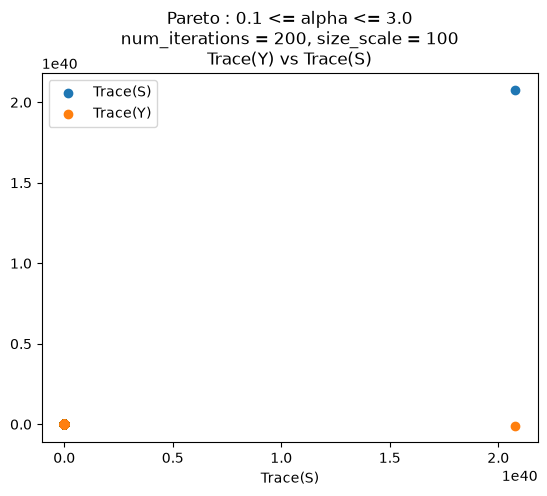

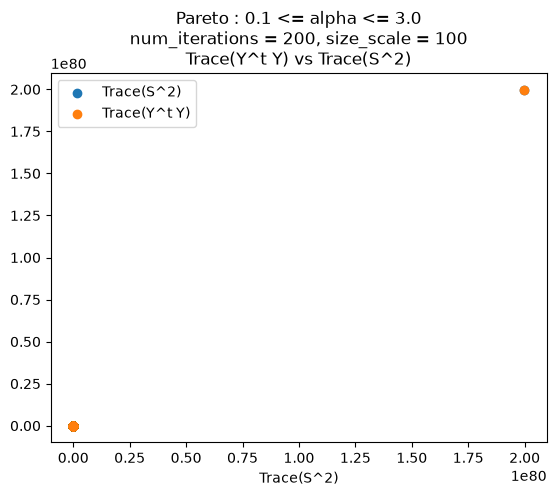


 fY = Trace(Y)^2 / Trace(YtY) 

shape : (200,)
min : 5.501292673058149e-07
max : 0.2669790843567736
sum : 1.2335746421103848
mean : 0.006167873210551924
std : 0.021959651503237827
norm : 0.3225736982722241


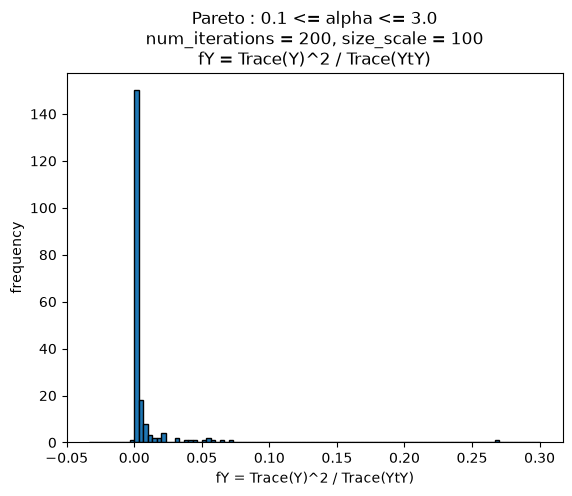


 fS = Trace(S)^2 / Trace(S^2) 

shape : (200,)
min : 1.228420451519265
max : 147.5676357993193
sum : 12299.693768748028
mean : 61.49846884374014
std : 41.53740228723933
norm : 1049.5158368406292


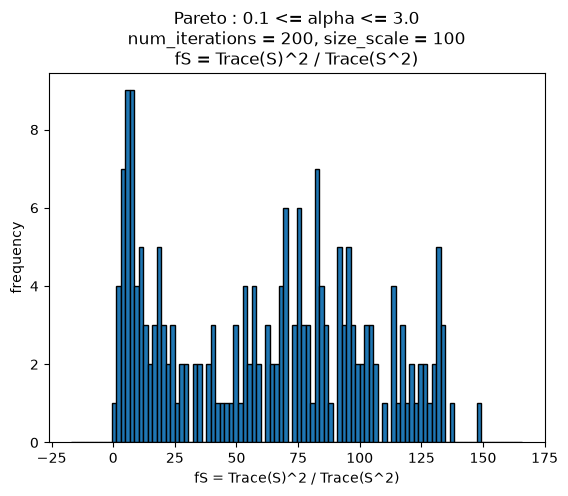

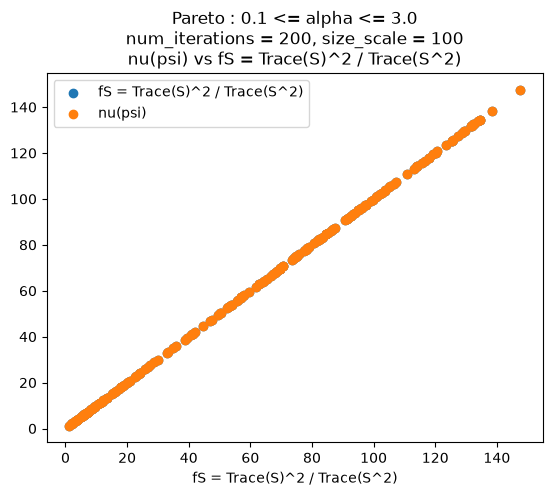


 fY / fS = (Trace(Y)^2 / Trace(YtY)) / Trace(S)^2 / Trace(S^2)) 

shape : (200,)
min : 7.326271451939742e-09
max : 0.011810535260846945
sum : 0.025833398441824973
mean : 0.00012916699220912487
std : 0.000844409262097987
norm : 0.012080654897754665


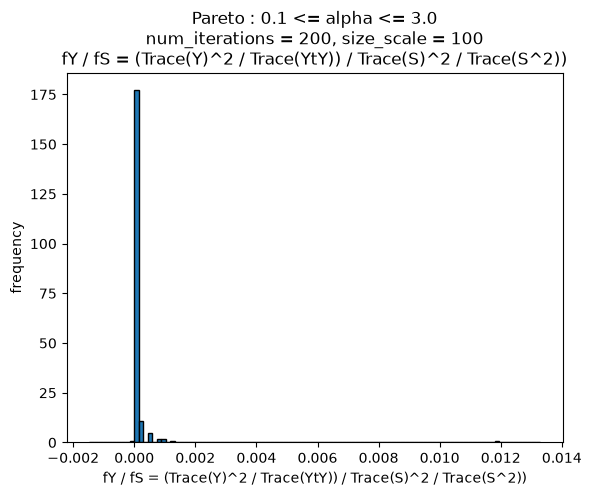


 fS / nu(psi) = (Trace(S)^2 / Trace(S^2)) / nu(psi) 

shape : (200,)
min : 1.0
max : 1.0
sum : 200.0
mean : 1.0
std : 0.0
norm : 14.142135623730951


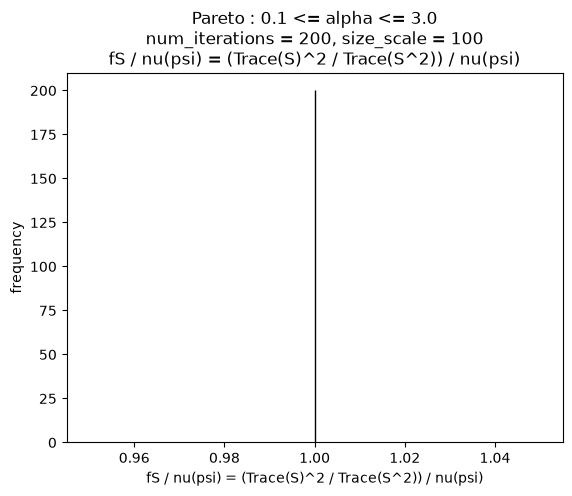


 Trace(Y) / Trace(S) 

shape : (200,)
min : -0.015592986033569572
max : 0.10867628656172854
sum : 0.10276506931747587
mean : 0.0005138253465873793
std : 0.011353544632507031
norm : 0.16072771522617052


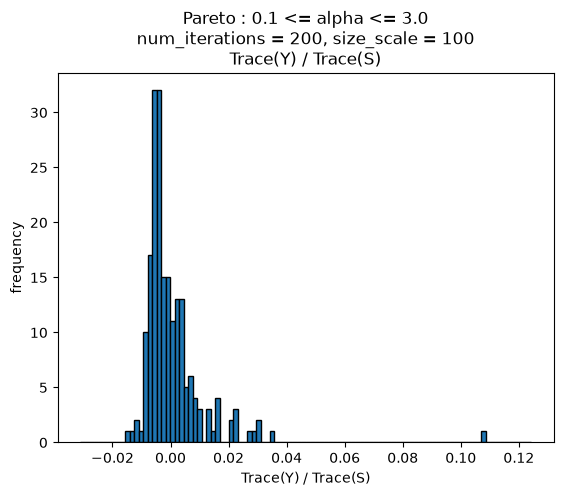


 Trace(YtY) / Trace(S^2) 

shape : (200,)
min : 0.9999999999999973
max : 1.0000000000000036
sum : 200.0
mean : 1.0
std : 8.033980693542652e-16
norm : 14.142135623730953


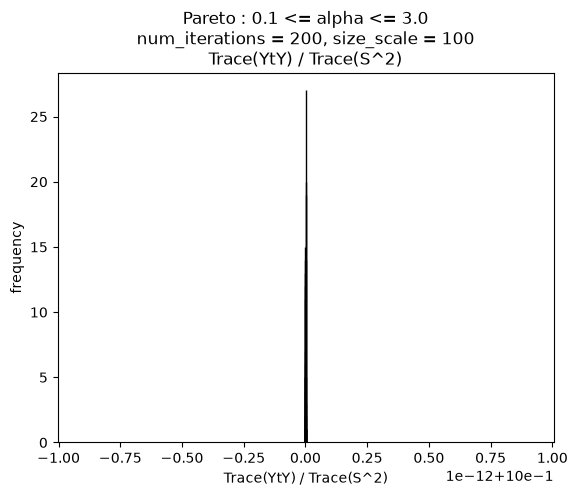

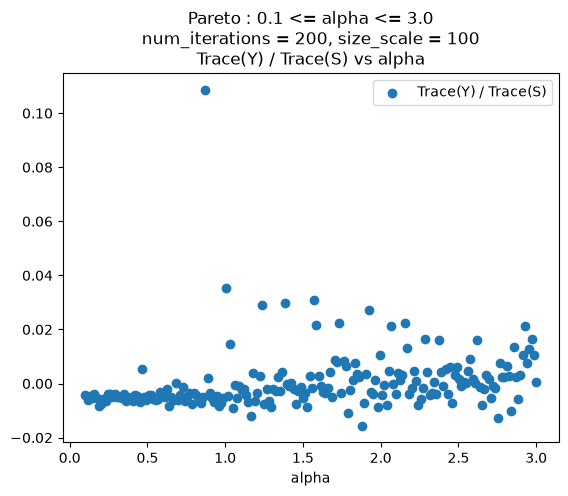

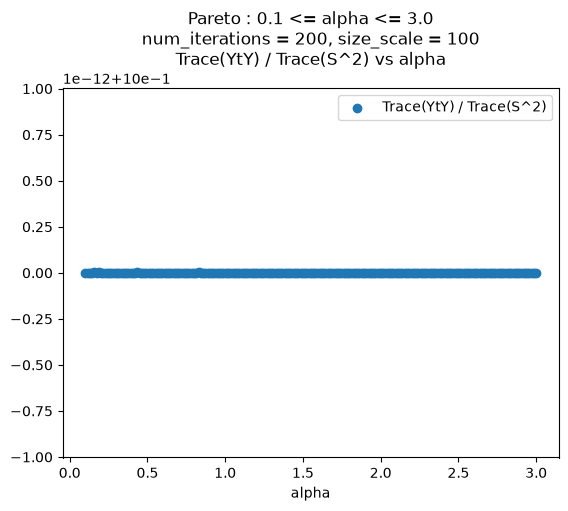

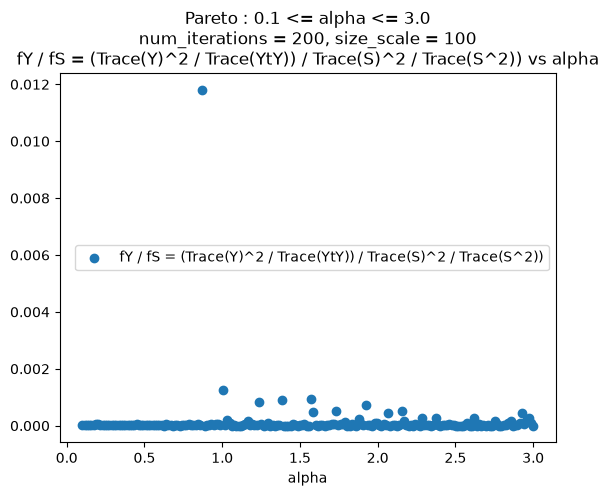

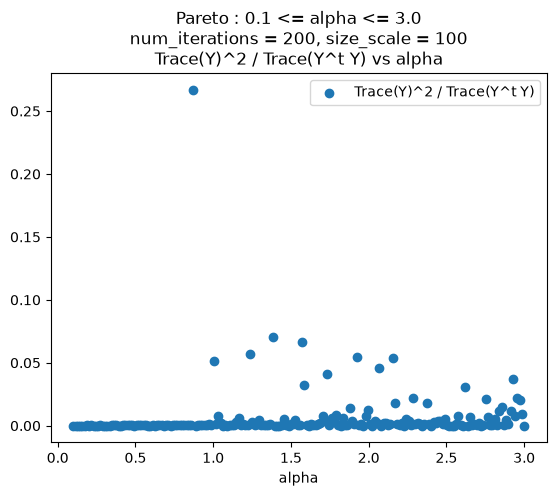

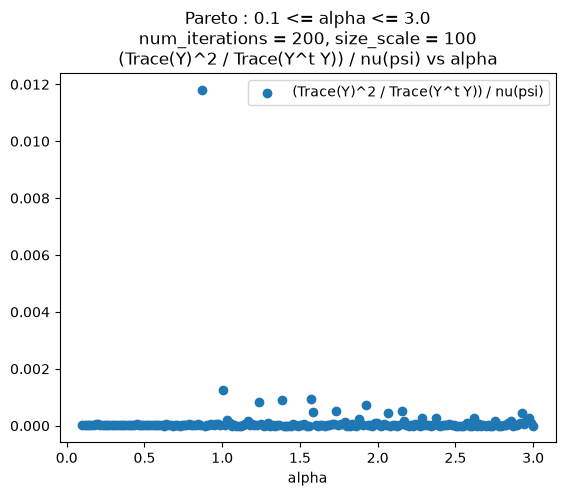

In [3]:
prefix = "Pareto : " + str(np.min(pareto_alpha_vals)) + " <= alpha <= " + str(np.max(pareto_alpha_vals)) + "\n"
prefix += "num_iterations = " + str(num_iterations) + ", size_scale = " + str(size_scale) + "\n"
#prefix = str(np.min(pareto_alpha_vals)) + " <= alpha <= " + str(np.max(pareto_alpha_vals)) + "\n"
pp.trace_Y_trace_S_experiment_plot_one(xx_pareto_ss_100_ni_200, prefix)

# 3.1 Pareto : fix alpha = 1.15

In [4]:
this_config = pp.trace_Y_trace_S_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_pareto"] = True 
this_config["size_scale"] = size_scale 
this_config["column_demean"] = True 

fixed_alpha = 1.15
pareto_alpha_vals = fixed_alpha * np.ones(num_iterations)
this_config["pareto_alpha_vals"] = pareto_alpha_vals

xx_pareto_a_115_ss_100_ni_200 = pp.trace_Y_trace_S_experiment(this_config)

Y.shape =  (287, 192) , mu_Y.shape =  (192,)
** calculate_nu_cpu ** running on CPU
0 N =  287 , d =  192
trace_Y =  1477.1603579935024 , trace_S =  83651.29726169586 , trace_Y / trace_S =  0.017658546924530456
trace_YtY =  119220628.89198443 , trace_Ssquared =  119220628.89198442 , trace_YtY / trace_Ssquared =  1.0000000000000002
(trace_Y ** 2) / (trace_YtY * nu_psi) =  0.000311824279485844
(trace_S ** 2) / (trace_Squared * nu_psi) =  1.0
0 0.00031182427948584396 1.0
Y.shape =  (251, 185) , mu_Y.shape =  (185,)
** calculate_nu_cpu ** running on CPU
1 N =  251 , d =  185
trace_Y =  -461.4390844414463 , trace_S =  70123.1926448383 , trace_Y / trace_S =  -0.006580406097288732
trace_YtY =  90462060.00507417 , trace_Ssquared =  90462060.00507423 , trace_YtY / trace_Ssquared =  0.9999999999999993
(trace_Y ** 2) / (trace_YtY * nu_psi) =  4.330174440523474e-05
(trace_S ** 2) / (trace_Squared * nu_psi) =  1.0
1 4.330174440523474e-05 1.0
Y.shape =  (219, 121) , mu_Y.shape =  (121,)
** calculate_

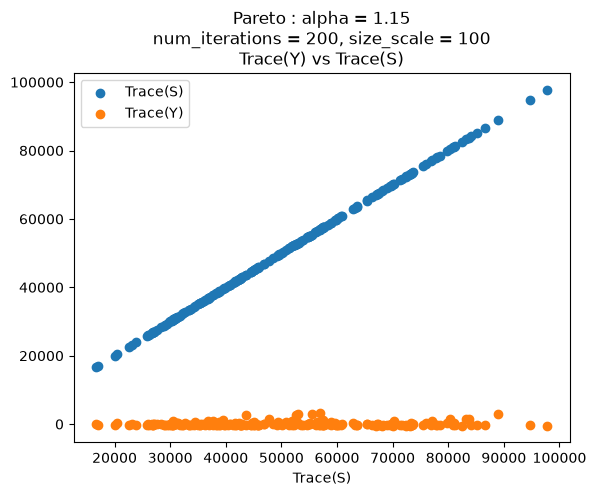

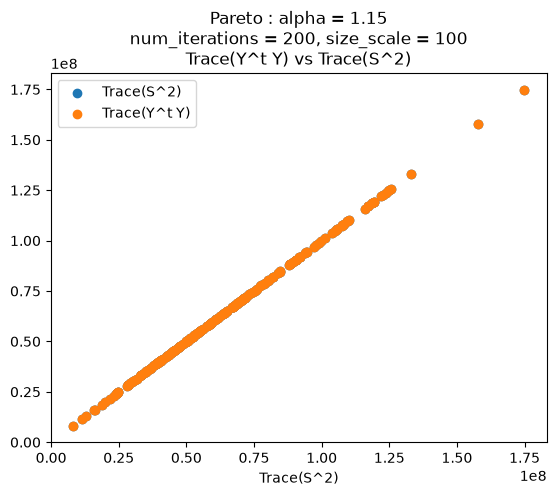


 fY = Trace(Y)^2 / Trace(YtY) 

shape : (200,)
min : 6.732090644059571e-07
max : 0.17119544613592927
sum : 1.192365287092915
mean : 0.005961826435464574
std : 0.021164743409407667
norm : 0.3109629360655927


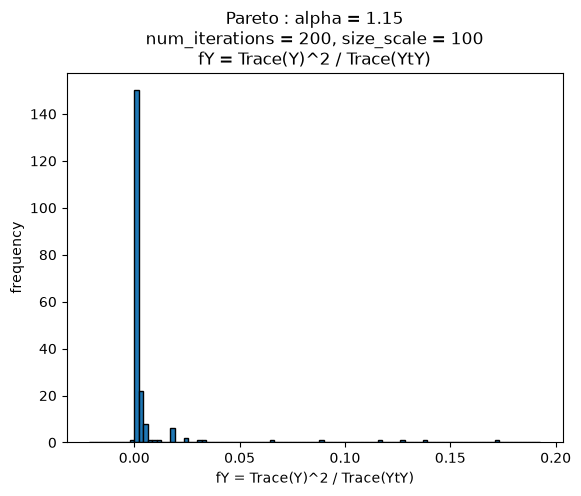


 fS = Trace(S)^2 / Trace(S^2) 

shape : (200,)
min : 14.514548102998402
max : 75.01075287975956
sum : 8176.12914811838
mean : 40.8806457405919
std : 12.079079064516066
norm : 602.8484630841493


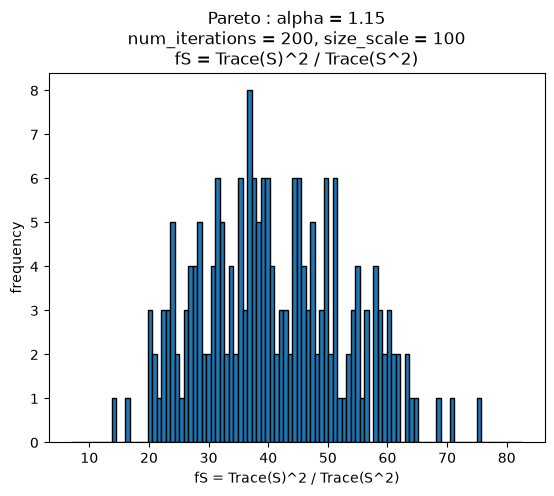

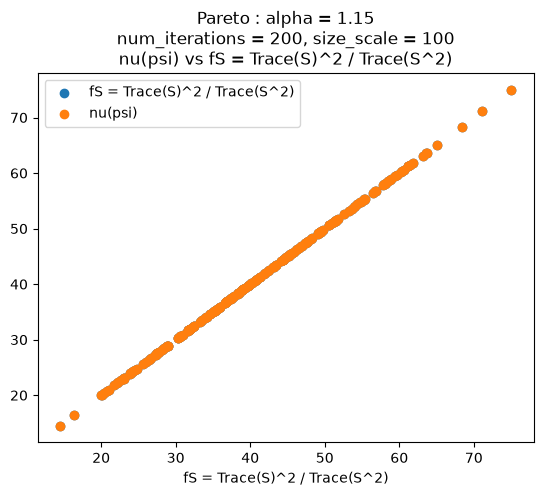


 fY / fS = (Trace(Y)^2 / Trace(YtY)) / Trace(S)^2 / Trace(S^2)) 

shape : (200,)
min : 1.6951367248916648e-08
max : 0.00376032218686443
sum : 0.029224644229858748
mean : 0.00014612322114929374
std : 0.0004925225660839373
norm : 0.007265403964831576


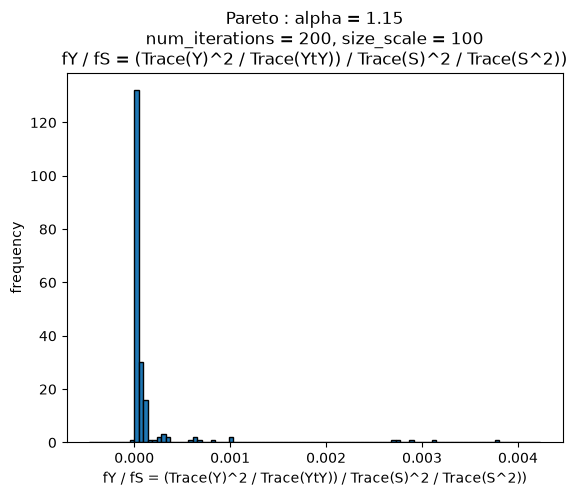


 fS / nu(psi) = (Trace(S)^2 / Trace(S^2)) / nu(psi) 

shape : (200,)
min : 1.0
max : 1.0
sum : 200.0
mean : 1.0
std : 0.0
norm : 14.142135623730951


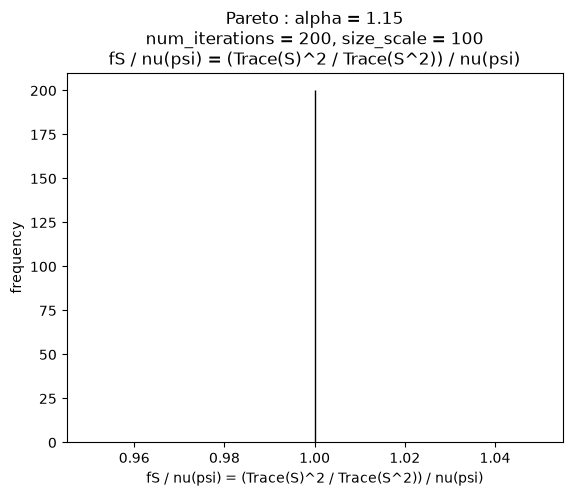


 Trace(Y) / Trace(S) 

shape : (200,)
min : -0.013519036232285089
max : 0.061321465954952775
sum : 0.192482960708257
mean : 0.0009624148035412849
std : 0.012049770906337529
norm : 0.17095216942132893


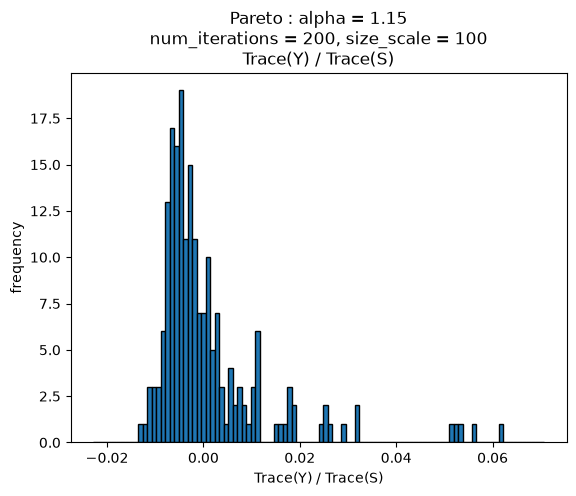


 Trace(YtY) / Trace(S^2) 

shape : (200,)
min : 0.9999999999999981
max : 1.0000000000000024
sum : 200.00000000000003
mean : 1.0000000000000002
std : 7.598744664527479e-16
norm : 14.142135623730953


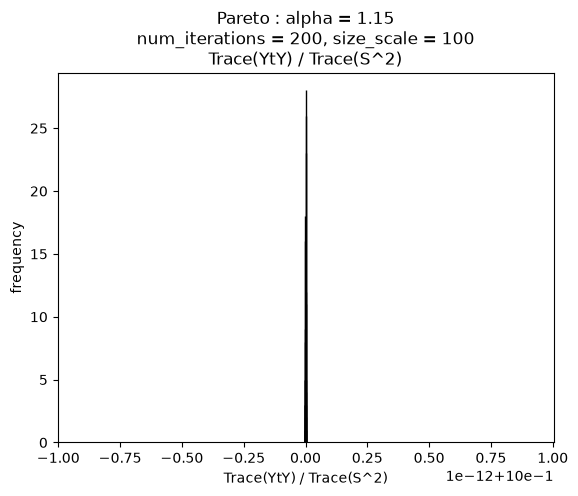

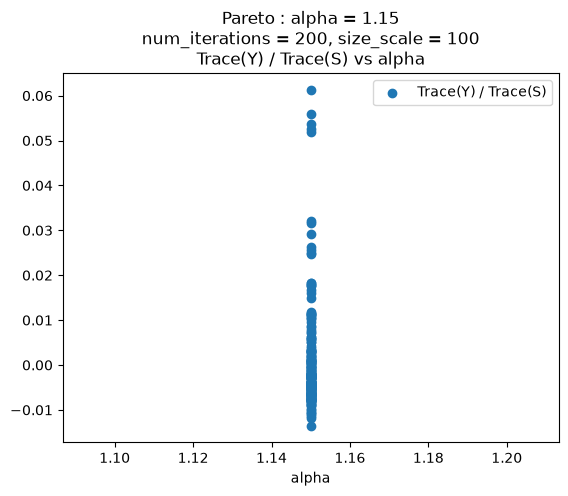

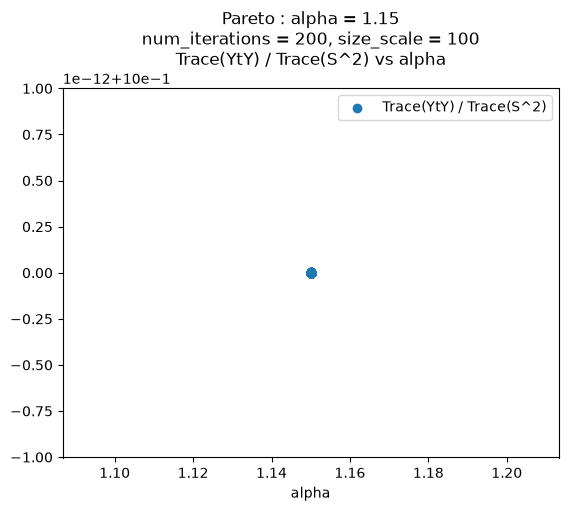

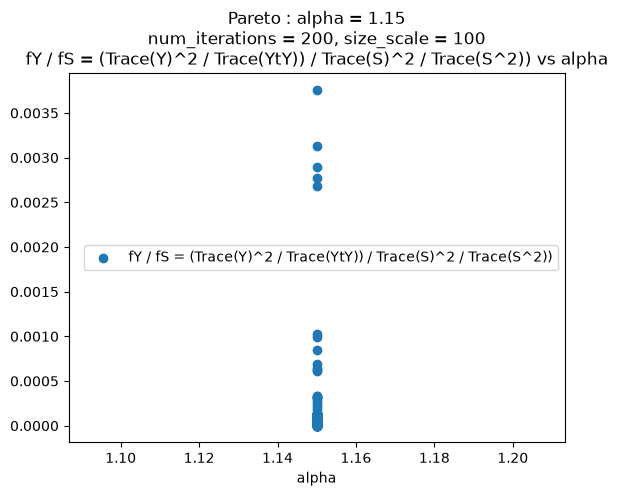

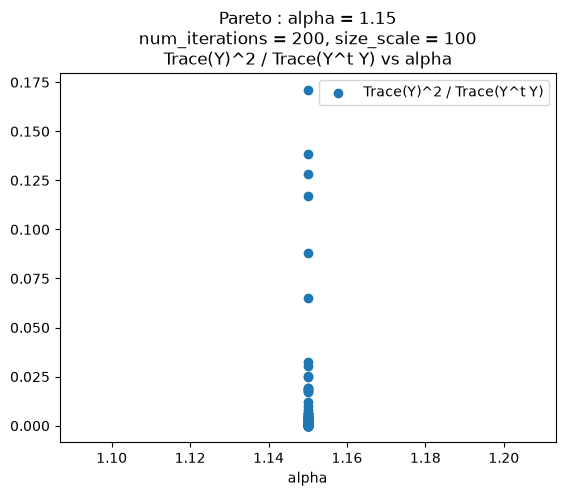

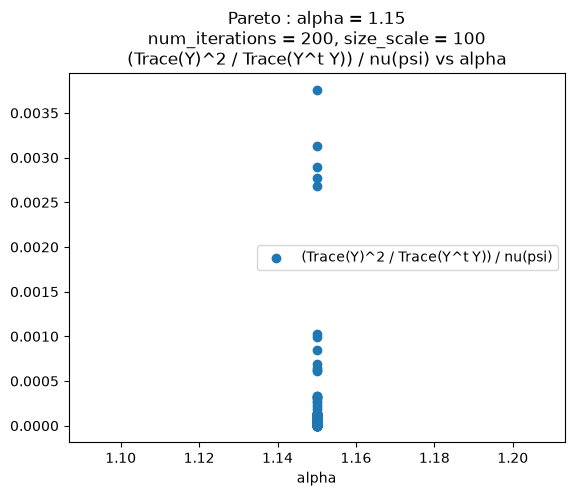

In [5]:
prefix = "Pareto : alpha = " + str(fixed_alpha) + "\n"
prefix += "num_iterations = " + str(num_iterations) + ", size_scale = " + str(size_scale) + "\n"
#prefix = str(np.min(pareto_alpha_vals)) + " <= alpha <= " + str(np.max(pareto_alpha_vals)) + "\n"
pp.trace_Y_trace_S_experiment_plot_one(xx_pareto_a_115_ss_100_ni_200, prefix)